In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
from sklearn.ensemble import RandomForestClassifier # Model 1, Random Forest
from sklearn.tree import DecisionTreeClassifier # Model 2, Decision Tree
from sklearn.linear_model import LogisticRegression # Model 3, Logistic Regression
from xgboost import XGBClassifier # Model 4, XGBoost

In [22]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [9]:
df = pd.read_csv("train.csv")

X = df.drop(columns=["readmitted"])
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Test AUC: 0.654
              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2718
           1       0.60      0.50      0.55      2282

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.62      0.62      0.61      5000

0.6184
                             gini
num_lab_procedures          0.121
num_medications             0.107
time_in_hospital            0.079
number_inpatient            0.059
number_diagnoses            0.053
...                           ...
acetohexamide_No            0.000
citoglipton_No              0.000
examide_No                  0.000
metformin-pioglitazone_No   0.000
metformin-rosiglitazone_No  0.000

[64 rows x 1 columns]


TypeError: missing a required argument: 'x'

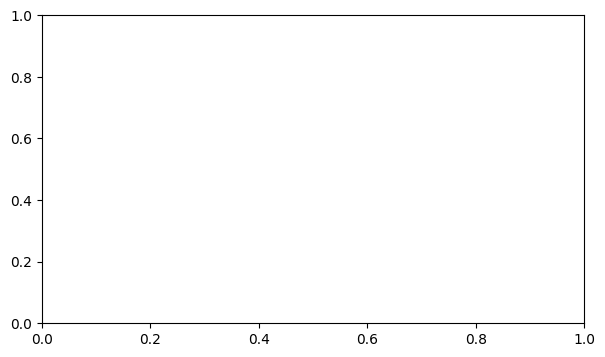

In [29]:
model1 = RandomForestClassifier(n_estimators=500, random_state=42)
model1.fit(X_train, y_train)

y_prob1 = model1.predict_proba(X_test)[:, 1]
y_pred1 = model1.predict(X_test)

auc1 = roc_auc_score(y_test, y_prob1)
print(f'Test AUC: {auc1:.3f}')
print(classification_report(y_test, y_pred1))
print(accuracy_score(y_test, y_pred1))

gini_imp = pd.Series(model1.feature_importances_, index=X.columns)
comparison = pd.DataFrame({'gini': gini_imp}).sort_values('gini', ascending=False).round(3)
print(comparison)

In [24]:
model2 = DecisionTreeClassifier(max_depth=8)
model2.fit(X_train, y_train)

y_prob2 = model2.predict_proba(X_test)[:, 1]
y_pred2 = model2.predict(X_test)

auc2 = roc_auc_score(y_test, y_prob2)
print(f'Test AUC: {auc2:.3f}')
print(classification_report(y_test, y_pred2))
print(accuracy_score(y_test, y_pred2))

gini_imp = pd.Series(model2.feature_importances_, index=X.columns)
comparison = pd.DataFrame({'gini': gini_imp}).sort_values('gini', ascending=False).round(3)
print(comparison)

Test AUC: 0.630
              precision    recall  f1-score   support

           0       0.62      0.72      0.66      2718
           1       0.58      0.46      0.52      2282

    accuracy                           0.60      5000
   macro avg       0.60      0.59      0.59      5000
weighted avg       0.60      0.60      0.60      5000

0.603
                              gini
number_inpatient             0.443
number_diagnoses             0.096
num_medications              0.059
num_lab_procedures           0.055
number_emergency             0.043
...                            ...
glyburide-metformin_No       0.000
glimepiride-pioglitazone_No  0.000
glipizide-metformin_No       0.000
metformin-pioglitazone_No    0.000
metformin-rosiglitazone_No   0.000

[64 rows x 1 columns]


In [25]:
model3 = LogisticRegression(penalty="l2", class_weight="balanced", C=0.05)
model3.fit(X_train, y_train)

y_prob3 = model3.predict_proba(X_test)[:, 1]
y_pred3 = model3.predict(X_test)

auc3 = roc_auc_score(y_test, y_prob3)
print(f'Test AUC: {auc3:.3f}')
print(classification_report(y_test, y_pred3))
print(accuracy_score(y_test, y_pred3))

gini_imp = pd.Series(model3.coef_[0], index=X.columns)
comparison = pd.DataFrame({'gini': gini_imp}).sort_values('gini', ascending=False).round(3)
print(comparison)

C:\Users\Danyl\anaconda3\envs\medds\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Test AUC: 0.652
              precision    recall  f1-score   support

           0       0.64      0.68      0.66      2718
           1       0.59      0.54      0.56      2282

    accuracy                           0.62      5000
   macro avg       0.61      0.61      0.61      5000
weighted avg       0.61      0.62      0.61      5000

0.6158
                                     gini
diag_1_428                          0.431
number_inpatient                    0.337
diabetesMed_Yes                     0.296
medical_specialty_Emergency/Trauma  0.259
race_AfricanAmerican                0.230
...                                   ...
glyburide-metformin_No             -0.143
diag_3_250                         -0.152
diag_2_250                         -0.221
diag_3_401                         -0.224
payer_code_BC                      -0.305

[64 rows x 1 columns]


C:\Users\Danyl\anaconda3\envs\medds\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
import re

X_train.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_train.columns]
X_test.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_test.columns]
model4 = XGBClassifier(n_estimators=500, random_state=42)
model4.fit(X_train, y_train)

y_prob4 = model4.predict_proba(X_test)[:, 1]
y_pred4 = model4.predict(X_test)

auc4 = roc_auc_score(y_test, y_prob4)
print(f'Test AUC: {auc1:.3f}')
print(classification_report(y_test, y_pred4))
print(accuracy_score(y_test, y_pred4))

gini_imp = pd.Series(model4.feature_importances_, index=X.columns)
comparison = pd.DataFrame({'gini': gini_imp}).sort_values('gini', ascending=False).round(3)
print(comparison)

Test AUC: 0.654
              precision    recall  f1-score   support

           0       0.62      0.66      0.64      2718
           1       0.56      0.53      0.54      2282

    accuracy                           0.60      5000
   macro avg       0.59      0.59      0.59      5000
weighted avg       0.60      0.60      0.60      5000

0.597
                              gini
number_inpatient             0.050
payer_code_BC                0.026
diag_1_428                   0.024
diabetesMed_Yes              0.022
age_[40-50)                  0.022
...                            ...
examide_No                   0.000
glimepiride-pioglitazone_No  0.000
glipizide-metformin_No       0.000
metformin-pioglitazone_No    0.000
metformin-rosiglitazone_No   0.000

[64 rows x 1 columns]
